# Stochastic Series Expansion for the Spin-1/2 Heisenberg Chain

- **Autor:** Théo HUET
- **Degree** Master 2 of Physics Thoeric
- **Institution** University of CY Cergy-Paris Université
- **Course** Quantum Monte Carlo, Andreas Honecker
- **Date** March, 2026

## 1. Introduction

### 1.1 Context and Motivation
The Stochastic Series Expansion (SSE) is a highly efficient Quantum Monte Carlo (QMC) method designed to study the thermodynamic properties of quantum lattice models at finite temperatures. Unlike methods based on the Suzuki-Trotter decomposition, SSE avoids systematic time-discretization errors by directly sampling the Taylor expansion of the partition function. This approach is essential for investigating many-body quantum systems where the Hilbert space grows exponentially, making exact diagonalization computationally impossible for large system sizes. By mapping the quantum problem onto a high-dimensional classical configuration space of operator sequences, SSE provides a powerful tool for obtaining high-precision results for magnetic and thermal observables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1.2 Theoretical Background
The core of this project is the study of the one-dimensional spin-1/2 Heisenberg model. The system is described by the following Hamiltonian:

$$H = J \sum_{i=1}^{L} \vec{S}_{i} \cdot \vec{S}_{i+1}$$

- where $L$ is the length of the chain and periodic boundary conditions are assumed, such that $L+1 \equiv 1$. Understanding this project requires familiarity with:
- **The Heisenberg Model:** A fundamental paradigm for describing exchange interactions between neighboring spins in magnetic materials.
- **Exchange Coupling ($J$):** The behavior of the system changes drastically depending on the sign of $J$, leading to either an Anti-ferromagnetic ($J=1$) or a Ferromagnetic ($J=-1$) ground state.
- **Magnetic Susceptibility ($\chi$):** A thermodynamic response function that characterizes how the magnetization of the system reacts to an external magnetic field, which we will compute as a function of temperature $T$.
- **Statistical Mechanics of SSE:** The representation of the partition function $Z = \text{Tr}(e^{-\beta H})$ as a summation over operator strings and spin states, with $\beta = \frac{1}{T k_B}$.

In [2]:
global L, J, beta

L = 50
J = -1. # Antiferro
beta = 1. # We gonna change it later

### 1.3 Objectives of the Project
The primary goal is to develop a robust numerical tool to simulate the magnetic properties of a 1D quantum spin chain. The specific objectives are:

1. **Algorithm Implementation:** Develop and implement the SSE algorithm tailored for the spin-1/2 Heisenberg chain.
2. **Thermodynamic Analysis:** Compute and plot the magnetic susceptibility $\chi(T)$ for both the anti-ferromagnetic ($J=1$) and ferromagnetic ($J=-1$) cases.
3. **Statistical Validation:** Implement rigorous thermalization protocols and estimate error bars by performing independent repetitions of the calculations to ensure the reliability of the results.

In [3]:
def init_spin_chain() -> np.ndarray: # random spin chain
  S = 1 #we take 1 for efficency
  return np.random.choice([-S, S], size=L)

def N_thermalization(Nt) -> int: # The system needs to reach thermal equilibrium before we can calculate the quantities
  return int(0.2 * Nt)

def error(quantitie:list, n_runs:int) -> float: # for the error bar
  return np.std(quantitie) / np.sqrt(n_runs)

---

## 2. Theoretical Framework

### 2.1 The SSE Partition Function

The starting point for any thermodynamic study in the canonical ensemble is the partition function $Z$ at an inverse temperature $\beta = 1/k_B T$. For a quantum system governed by a Hamiltonian $H$, the partition function is defined as the trace of the density matrix:

$$Z = \text{Tr}(e^{-\beta H}) = \sum_{\alpha} \langle \alpha | e^{-\beta H} | \alpha \rangle$$

where $\{|\alpha\rangle\}$ is an orthonormal basis of the Hilbert space (typically the computational basis in the $S^z$ representation for spin systems). By expanding the exponential operator into its power series $e^{-\beta H}= \sum_{n=0}^{\infty} \frac{\beta^n}{n!}(-H)^n$, we obtain:

$$Z = \sum_{\alpha} \sum_{n=0}^{\infty} \frac{\beta^n}{n!} \langle \alpha | (-H)^n | \alpha \rangle$$

This formulation transforms the problem into a summation over all possible states $|\alpha\rangle$ and all possible expansion orders $n$. In a numerical simulation, the infinite sum is truncated at a sufficiently large cut-off $M$, such that the contribution of terms with $n > M$ is negligible.

### 2.2 The Configuration Space

In the SSE framework, the "configurations" sampled by the Monte Carlo algorithm are not just physical states, but pairs $(|\alpha\rangle, S_n)$, where:
* $|\alpha\rangle$ is an initial state of the basis.
* $S_n$ is an **operator string** consisting of a sequence of $n$ local components of the Hamiltonian $H$.

The weight of a specific configuration is determined by the matrix element $\langle \alpha | H^n | \alpha \rangle$. For this weight to be easily computable and non-negative (to avoid the infamous "sign problem"), we must decompose the global Hamiltonian $H$ into a sum of elementary, local bond operators.

This leads us to the necessity of rewriting our Heisenberg Hamiltonian in a form that distinguishes between diagonal and non-diagonal contributions.

### 2.3 Hamiltonian Decomposition and Sublattice Transformation
To implement the SSE, we decompose the Hamiltonian $H$ into a sum of local bond operators $H_{a,b}$, where $b$ denotes a bond $(i, i+1)$ and $a \in \{1, 2\}$ indicates the type of operator (diagonal or off-diagonal). We aim for a form:
$$-H = \sum_{b=1}^{L} (H_{1,b} + H_{2,b}) + \text{const}$$

Using the identity $\vec{S}_{i} \cdot \vec{S}_{j} = S_i^zS_j^z + \frac{1}{2} (S_i^+ S_j^- + S_i^- S_j^+)$, the Heisenberg Hamiltonian is:
$$H = J \sum_{i=1}^{L} \left[ S_i^z S_{i+1}^z + \frac{1}{2}(S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+) \right]$$

For the **Ferromagnet** ($J=-1$), the terms in $-H$ are naturally positive. However, for the **Antiferromagnet** ($J=1$), the off-diagonal terms in $-H$ would be negative, leading to a sign problem. Since the 1D chain is a bipartite lattice, we apply a unitary transformation (a $\pi$-rotation around the $z$-axis) on one sublattice: $S_j^\pm \to -S_j^\pm$ and $S_j^z \to S_j^z$. This yields the following bond operators for both cases:

* **Diagonal Operator ($a=1$):** $H_{1,b} = \frac{1}{4} - S_i^z S_{i+1}^z$
* **Off-diagonal Operator ($a=2$):** $H_{2,b} = \frac{1}{2}(S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+)$

This leads to the convenient form:
$$-H = \sum_{b=1}^L (H_{1,b} + H_{2,b}) - \frac{L}{4}$$

### 2.4 Positivity of Operator Weights
A crucial requirement for Monte Carlo sampling is that all configuration weights must be non-negative. Let's examine the action of our operators on the local basis $\{|\uparrow\uparrow\rangle, |\uparrow\downarrow\rangle, |\downarrow\uparrow\rangle, |\downarrow\downarrow\rangle\}$:

**For the Diagonal Operator $H_{1,b}$:**
* $H_{1,b} |\uparrow\uparrow\rangle = (\frac{1}{4} - \frac{1}{4}) |\uparrow\uparrow\rangle = 0$
* $H_{1,b} |\downarrow\downarrow\rangle = (\frac{1}{4} - \frac{1}{4}) |\downarrow\downarrow\rangle = 0$
* $H_{1,b} |\uparrow\downarrow\rangle = (\frac{1}{4} - (-\frac{1}{4})) |\uparrow\downarrow\rangle = \frac{1}{2} |\uparrow\downarrow\rangle$
* $H_{1,b} |\downarrow\uparrow\rangle = (\frac{1}{4} - (-\frac{1}{4})) |\downarrow\uparrow\rangle = \frac{1}{2} |\downarrow\uparrow\rangle$

**For the Off-diagonal Operator $H_{2,b}$:**
* $H_{2,b} |\uparrow\uparrow\rangle = 0$
* $H_{2,b} |\downarrow\downarrow\rangle = 0$
* $H_{2,b} |\uparrow\downarrow\rangle = \frac{1}{2} |\downarrow\uparrow\rangle$
* $H_{2,b} |\downarrow\uparrow\rangle = \frac{1}{2} |\uparrow\downarrow\rangle$

In all cases, the non-zero matrix elements are $\langle \alpha' | H_{a,b} | \alpha \rangle = 1/2$. The weights are strictly non-negative, ensuring a sign-problem-free simulation.

### 2.5 Fixed-Length Operator String Representation
To handle the summation over $n$ efficiently, we introduce a fixed-length expansion. We truncate the series at a maximum cutoff $M$ and fill the remaining $M-n$ slots with the identity operator $H_{0,0} \equiv I$. The number of ways to arrange $n$ operators in $M$ slots is given by the binomial coefficient $\binom{M}{n}$.

The partition function $Z$ is rewritten as:
$$Z = \sum_{\alpha} \sum_{S_M} \frac{\beta^n (M-n)!}{M!} \langle \alpha | \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle$$

where $S_M$ is the operator string of length $M$ containing $n$ active operators ($a>0$) and $M-n$ identities ($a=0$). The weight of a specific configuration $(\alpha, S_M)$ is thus:
$$W(\alpha, S_M) = \beta^n \frac{(M-n)!}{M!} \left( \frac{1}{2} \right)^n$$

This weight will be used in the Metropolis-Hastings updates to sample the configuration space.

---

## 3. Numerical Implementation

Moving from the theoretical expansion to a computational algorithm requires an efficient way to store and manipulate the sequence of operators.

### 3.1 Operator String Representation

The operator string $S_M$ is the central object of the SSE algorithm. We represent it using a one-dimensional NumPy array of fixed length $M$, where $M$ is the truncation cutoff of the Taylor expansion.

Initially, the string is populated with identity operators. To distinguish between the different types of operators (Identity, Diagonal, and Off-diagonal) and the specific bonds they act upon, we use an integer encoding scheme. Given a bond index $b \in \{0, 1, \dots, L-1\}$, the encoding is defined as follows:

* **Identity Operator ($H_{0,0}$):** Represented by `-1`.
* **Diagonal Operator ($H_{1,b}$):** Represented by an even integer `2b`.
* **Off-diagonal Operator ($H_{2,b}$):** Represented by an odd integer `2b + 1`.

In this convention, the bond index $b$ can be retrieved easily via integer division.

Each integer in the `op_string` (if not -1) points to a specific bond $b$ connecting two sites $(i, j)$ in the 1D chain. With periodic boundary conditions, site $i$ is connected to $j = (i+1) \pmod L$.

This representation is highly efficient for the Monte Carlo updates, as checking whether an operator is diagonal or off-diagonal simply requires checking the parity of the integer, and the identity operator is handled as a special case.


In [4]:
def init_op_strings(M:int) -> np.ndarray :
  return -np.ones(M, dtype=int)  # all are -1 : identity

def compute_bond(op_string_p:float) :
  assert op_string_p != -1 # identity
  bond = op_string_p // 2
  return bond, (bond + 1) % L

---

### 3.2 Diagonal Update

The diagonal update is the primary mechanism for changing the expansion order $n$ in the Stochastic Series Expansion. In this step, we explore different operator string lengths by attempting to insert or remove diagonal operators.

In this procedure, we iterate through all $M$ slots of the operator string. At each step, the action depends on the type of operator currently occupying the slot:

* **Identity Operator ($a=0$):** We propose replacing it with a diagonal operator. We randomly pick a bond $b$ from the $L$ possibilities. Since the diagonal operator only yields a non-zero matrix element for antiparallel spins, we first verify that the spins at the ends of the bond are antiparallel. If they are, we accept the insertion with a Metropolis probability based on the weight ratio : $\frac 12$ and the proposal probabilities.
$$P_{\text{insert}} = \min \left( 1, \frac{\beta J L}{2(M-n)} \right)$$
The factor of $1/2$ comes directly from the matrix element of the local bond operator acting on an antiparallel spin pair, while the factor $L$ accounts for the selection probability of choosing one bond out of the $L$ available in the system.

* **Diagonal Operator ($a=1$):** We propose replacing it with an identity operator. The removal is accepted with the corresponding reverse Metropolis probability.
$$P_{\text{remove}} = \min \left( 1, \frac{2(M-n+1)}{\beta J L} \right)$$
* **Off-Diagonal Operator ($a=2$):** During the diagonal update, off-diagonal operators are left untouched. However, we must flip the values of the two spins involved in the off-diagonal operator to correctly propagate the state $|\alpha\rangle$ for the subsequent slots in the loop.

We only insert and remove diagonal operators because they act on the local state without altering the spin configuration. This local property makes them ideal for simple Metropolis steps. Off-diagonal operators, which create kinks in the spin trajectories, are much more efficiently updated using non-local cluster updates (such as loop updates) that flip entire connected pathways of spins and operators simultaneously.

In [5]:
def insertion(op_string:np.ndarray, M:int, n:int, p:int, bond:int) ->int:
    if n == M : #impossible de faire l'insertion
        return n
    else :
        prob = (beta * np.abs(J)*L) / (2. * (M - n))
    if np.random.rand() <  min(1., prob):
        op_string[p] = 2 * bond
        n += 1
    return n

def remove(op_string:np.ndarray, M:int, n:int, p:int) ->int:
    prob = (2. *(M - n + 1)) / (beta * np.abs(J) * L)
    if np.random.rand() <  min(1., prob):
        op_string[p] = -1
        n -= 1
    return n

def diagonal_update(spins:np.ndarray, op_string:np.ndarray, M:int, n:int) -> int:
    spins_p = spins.copy()
    for p in range(M):
        op = op_string[p]
        if op == -1 : # identity
            bond = np.random.randint(0, L)
            i = bond
            j = (bond + 1) % L

            if spins_p[i] != spins_p[j]: # insertion possible?
                n = insertion(op_string, M, n, p, bond)

        elif op % 2 == 0 : # diagonal
            n = remove(op_string, M, n, p)
        else : # off-diagonal
            i, j = compute_bond(op)
            spins_p[i] *= -1
            spins_p[j] *= -1
    return n

---

### 3.3 Linked Vertex List Construction

To perform non-local updates (the "Loop Updates"), the algorithm needs to navigate through the configuration space efficiently. While the operator string is stored as a linear sequence, the physical connectivity of the spins creates a complex graph. The **Linked Vertex List** is the data structure that maps this connectivity.

#### The Vertex Model
Each operator $H_{a,b}$ in the string at a position $p$ can be viewed as a **vertex** with four "legs" or ports, representing the state of the two spins involved before and after the operator acts:
* **Legs $4p$ and $4p+1$:** The input states (bottom legs) for sites $i$ and $j$ of bond $b$.
* **Legs $4p+2$ and $4p+3$:** The output states (top legs) for the same sites $i$ and $j$.

The total size of the link list is therefore $4M$, where $M$ is the truncation cutoff. This list stores the "address" of the next (or previous) leg connected to any given leg.

#### Spatial and Temporal Connectivity
The construction of the link list follows two types of connections:

1.  **Internal Vertex Connections:** Within a single vertex at position $p$, the connectivity depends on the operator type. For a diagonal operator, the state of a site is preserved, creating a logical link between its input and output legs. For an off-diagonal operator, the spins are swapped, which is reflected by cross-linking the input of one site to the output of the other. These internal links define how a "loop" will pass through an operator.
2.  **External Temporal Connections:** This is the core of the construction. For each physical site $x \in \{0, \dots, L-1\}$, we must link the output leg of an operator acting on $x$ at a certain "time" (position $p$) to the input leg of the *next* operator acting on that same site later in the sequence.

#### Handling the Trace and Periodicity
The partition function $Z = \text{Tr}(e^{-\beta H})$ implies a trace over the Hilbert space, which imposes a periodic boundary condition in the "imaginary time" direction. Numerically, this means that for each site:
* The very first operator acting on site $x$ must be linked to the very last operator acting on site $x$.
* If a site $x$ is not acted upon by any operator in the current string (only identities), it is effectively a straight line and is handled separately or ignored by the vertex-based loop.

To build this list in a single pass $O(M)$, we track the "last seen" leg for each site. When a new operator is encountered, we link its input legs to the stored "last legs" of the corresponding sites and then update the storage with the current output legs.

Once the `links` array is fully populated, every leg in the sequence (excluding those belonging to identity operators) is connected to exactly one other leg. This transforms the operator string into a set of closed, disjoint loops, which is the necessary prerequisite for the **Loop Update**.

In [6]:
def connexion(site:int, last_leg:np.ndarray, first_leg:np.ndarray, links:np.ndarray, leg_in:int, leg_out:int):
    """connecter entrée actuelle à sortie précédent
    mettre à jour la sortie"""
    if last_leg[site] == -1: # si première occurrence
        first_leg[site] = leg_in
    else: # si déja vu
        prev = last_leg[site]
        links[leg_in] = prev
        links[prev] = leg_in

    last_leg[site] = leg_out

def compute_link_list(op_string:np.ndarray, M:int) -> np.ndarray:
    links = -np.ones(4*M, dtype=int) # leg non connecté = -1

    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        # legs index
        leg0 = 4*p + 0  # i entrée
        leg1 = 4*p + 1  # j entrée
        leg2 = 4*p + 2  # i sortie
        leg3 = 4*p + 3  # j sortie

        op = op_string[p]
        if op == -1: # ignore les identitées car elle ne créent pas de vertex
            continue
        elif op % 2 == 0: # diagonal
            links[leg0] = leg2 # i->i
            links[leg2] = leg0

            links[leg1] = leg3 # j->j
            links[leg3] = leg1
        else: # off-diagonal => swapp
            links[leg0] = leg3 # i->j
            links[leg3] = leg0

            links[leg1] = leg2 # j->i
            links[leg2] = leg1

        i, j = compute_bond(op)

        connexion(i, last_leg, first_leg, links, leg_in=leg0, leg_out=leg2)
        connexion(j, last_leg, first_leg, links, leg_in=leg1, leg_out=leg3)

    for site in range(L): # fermeture periodique
        if first_leg[site] != -1:
            links[first_leg[site]] = last_leg[site]
            links[last_leg[site]] = first_leg[site]
    return links

---

### 3.4 Off-Diagonal (Loop) Update

While the diagonal update modifies the expansion order $n$, it is restricted to the diagonal sector and cannot change the spin configuration $|\alpha\rangle$ or the number of off-diagonal operators. To ensure ergodicity and explore the full Hilbert space, we implement the **Loop Update** (or Off-diagonal update). This is a cluster-type update that identifies closed paths of interconnected spin states and operators, flipping them simultaneously.

#### The Concept of Directed Loops
In the SSE representation, the configuration can be viewed as a set of "spin lines" connected by vertices. Because every operator $H_{a,b}$ (diagonal or off-diagonal) has exactly two incoming and two outgoing legs with non-zero weights, the entire configuration is naturally decomposed into a set of disjoint, closed loops.

Each loop consists of a sequence of legs linked either:
* **Temporally/Spatially:** Connecting an output leg of one vertex to the input leg of the next vertex acting on the same site.
* **Internally:** Connecting legs within the same vertex according to the operator's matrix elements.

#### Global Update Mechanism
The update proceeds by identifying all unique loops in the current configuration. For each loop, we make a stochastic decision (typically with a probability $P = 0.5$) to "flip" it. Flipping a loop involves two simultaneous operations:

1.  **Spin Flipping:** Every spin segment belonging to the loop is inverted ($S^z \to -S^z$). This allows the algorithm to move between different magnetization sectors and explore the state space efficiently, especially at low temperatures where local flips would likely be rejected.
2.  **Operator Transformation:** When a loop passes through a vertex, flipping the spin states at the vertex ports requires changing the operator type to maintain a non-zero weight. Specifically, a diagonal operator $H_{1,b}$ is transformed into an off-diagonal operator $H_{2,b}$, and vice versa. Identity operators are ignored as they do not participate in the vertex structure.

#### Implementation Details
The algorithm traverses the `links` list constructed in the previous step. By keeping track of "visited" legs, we ensure that every leg is assigned to exactly one loop. For each loop selected for flipping, we iterate through its constituent legs to:
* Determine the physical site associated with the leg and flip its corresponding spin value.
* Identify the vertex (position $p$ in the operator string) and toggle its type between even (diagonal) and odd (off-diagonal) encoding.

By flipping entire loops, the algorithm performs a global update that satisfies detailed balance while maintaining the "ice-rule" (continuity of spin lines) at each vertex. This non-local movement is what makes SSE extremely efficient for 1D systems, as it bypasses the critical slowing down often encountered in local Monte Carlo methods.

In [7]:
def leg_to_site(leg:int, op_string:np.ndarray) -> int:
  p = leg // 4
  leg_type = leg % 4
  b = op_string[p] // 2

  i = b
  j = (b+1) % L

  if leg_type in [0, 2]:
      return i
  else:
      return j

def loop_update(spins:np.ndarray, op_string:np.ndarray, links:np.ndarray, M:int) :
    visited_leg = np.zeros(4*M, dtype=bool)

    for start in range(4*M):
        # create the loop
        if visited_leg[start] or links[start] == -1: # si déja visité ou non connécté on ne fait rien
            continue

        current = start
        loop_legs = []

        while True:
            visited_leg[current] = True
            loop_legs.append(current)

            assert links[links[current]] == current # si diag => i->i->i, si off-diag => i->j->i si links est bien fait

            current = links[current] # suivre lien
            if current == start:
                break
        # flip
        if np.random.rand() < 0.5:
            vertices = set()# set permet deviter de passer plusieur fois sur le meme vertex
            visited_sites = set()# set permet deviter de passer plusieur fois sur le meme site
            # spins change
            for leg in loop_legs:
              p = leg // 4

              if op_string[p] == -1:
                  continue

              site = leg_to_site(leg, op_string)
              if site not in visited_sites:
                spins[site] *= -1
                visited_sites.add(site)

              vertices.add(p)

            #vertices change
            for p in vertices:
                # flip vertex
                if op_string[p] == -1:
                    continue
                elif op_string[p] % 2 == 0:
                    op_string[p] += 1   # diag → off-diag
                else:
                    op_string[p] -= 1   # off-diag → diag

---

## 4. Measurements and Observables

Once the system has reached thermal equilibrium (thermalization), we can begin to sample physical observables. In the SSE framework, these observables are expressed as averages over the sampled expansion order $n$ and the spin configurations $|\alpha\rangle$.

To simplify the calculations, we set $k_B = 1$.

### 4.1 Computation furmula

#### Internal Energy

- $e = -\frac{\langle n\rangle}{\beta L} + \frac{J}4$

#### Magnetization

- $m = \frac{\langle\sum_{i=1}^L s_i\rangle}L$

We previously assumed spin values of $\pm 1$ for the efficiency, but as our physical system consists of particles with spin $1/2$, we must not forget to include a factor of $1/2$ when calculating the magnetisation.

#### Susceptibility

- $\chi = \beta \frac {\langle M^2 \rangle} L= \beta {\langle m^2 \rangle} L$

#### Specific heat

- $C = \langle n^2 \rangle - \langle n\rangle^2 - \langle n \rangle$

Pour notre projet nous calculerons ces valeurs par spin donc elles seront divisé par L

In [8]:
def compute_energy(n:list)->float:
    return -np.mean(n) / (beta*L) # (J/4) # la constante de décalage

def compute_magnetisation(spins:np.ndarray)->float:
    S = 0.5 # cause we take |spins| = 1
    return np.sum(spins)*S/L

def compute_susceptibility(m:list)->float:
    return beta * np.mean(np.array(m)**2)*L

def compute_specific_heat(n:list)->float:
    return (np.mean(np.array(n)**2) - np.mean(n)**2 - np.mean(n))/L

---

### 4.2 Theoretical Limits: Antiferromagnetic Case ($J=+1$)

To validate our Quantum Monte Carlo implementation, we compare our numerical results against exact analytical limits derived from the Bethe Ansatz, Conformal Field Theory (CFT), and high-temperature expansions. For the isotropic spin-1/2 antiferromagnetic Heisenberg chain ($J=1$), the expected behaviors per site are as follows:

#### Internal Energy ($e = E/L$)
* **Low Temperature:** The system is described by a Tomonaga-Luttinger liquid. The energy follows a CFT prediction:
$$e(T) \approx E_0 + \frac{\pi v}{6} T^2$$
where the spin velocity is $v = \frac{\pi J}{2}$ and the exact ground-state energy is $E_0 = \frac{1}{4} - \ln(2) \approx -0.443147$.
* **High Temperature:** Expanding the partition function yields:
$$e(T) \approx -\frac{3J^2}{16T}$$

#### Magnetization ($m = \langle M_z \rangle / L$)
* In the absence of an external magnetic field, the $SU(2)$ symmetry remains unbroken, and the macroscopic magnetization is strictly zero at all temperatures:
$$m(T) = 0 \quad \forall T$$

#### Magnetic Susceptibility ($\chi$)
* **Low Temperature:** The susceptibility approaches a finite zero-temperature limit $\chi_0 = \frac{1}{\pi^2 J} \approx 0.10132$. Furthermore, the low-$T$ behavior is famously dominated by logarithmic corrections rather than a simple power law, taking the form:
$$\chi(T) \approx \chi_0 \left[ 1 + \frac{1}{2 \ln(T_0 / T)} \right]$$
where $T_0$ is a characteristic temperature scale.
* **High Temperature:** The spins become uncorrelated, and the system follows the standard Curie law for non-interacting spin-1/2 particles:
$$\chi(T) \approx \frac{1}{4T}$$

#### Specific Heat ($C$)
* **Low Temperature:** Deriving the low-$T$ energy yields a linear specific heat, characteristic of 1D gapless quantum systems:
$$C(T) \approx \frac{2}{3J} T$$
* **High Temperature:** Derived from the energy fluctuation expansion:
$$C(T) \approx \frac{3J^2}{16T^2}$$

In [9]:
global T_intermediate
T_intermediate = 0.5
T_low = 0.3
T_low = 2

def compute_E_theoric_antiferro(T:np.ndarray) -> np.ndarray:
  E0 = -0.443147 # a T=0
  v = np.pi*J/2
  E_theoric_low_T = E0 + np.pi * v * T**2 / 6

  E_theoric_high_T = - 3 * J**2/(16*T)

  return np.where(T < T_intermediate, E_theoric_low_T, E_theoric_high_T)

def compute_m_theoric_antiferro(T:np.ndarray) -> np.ndarray:
  return np.zeros_like(T)

def compute_susceptibility_theoric_antiferro(T:np.ndarray) -> np.ndarray:
  chi0 = 0.10132 # a T=0
  T0 = 7.7
  susceptibility_theoric_low_T = chi0 * (1 + 1/(2*np.log(T0/T)))

  susceptibility_theoric_high_T = 1/(4*T)

  return np.where(T < T_intermediate, susceptibility_theoric_low_T, susceptibility_theoric_high_T)

def compute_specific_heat_theoric_antiferro(T:np.ndarray) -> np.ndarray:
  specific_heat_theoric_low_T = T * 2/(3*J)

  specific_heat_theoric_high_T = 3*(J**2)/(16*(T**2))

  return np.where(T < T_intermediate, specific_heat_theoric_low_T, specific_heat_theoric_high_T)

### 4.3 Theoretical Limits: Ferromagnetic Case ($J=-1$)

The ferromagnetic Heisenberg chain ($J=-1$) presents a different physical behavior, especially at low temperatures.

#### Internal Energy ($e = E/L$)
- **Low Temperature:** Unlike the $T^2$ dependence seen in the antiferromagnet, the quadratic dispersion of magnons in 1D leads to:
$$e(T) \approx E_0 + \zeta(3/2) \sqrt{\frac{1}{4\pi |J|}} T^{3/2}$$
where $E_0 = J/4 = -0.25$ is the exact ground-state energy per site and $\zeta(3/2)\approx 2.612375$.
- **High Temperature:** The energy converges toward the same limit as the antiferromagnetic case:
$$e(T) \approx -\frac{3J^2}{16T}$$

#### Magnetization ($m = \langle M_z \rangle / L$)
- In accordance with the Mermin-Wagner theorem, spontaneous symmetry breaking is impossible in 1D at $T > 0$. Therefore, even for the ferromagnet:
$$m(T) = 0 \quad \forall T > 0$$
However, at exactly $T=0$, the system is in a fully polarized state where $|m| = 1/2$.

#### Magnetic Susceptibility ($\chi$)
- **Low Temperature:** The susceptibility diverges much more rapidly than the Curie law as $T \to 0$. Spin-wave theory and Bethe Ansatz calculations show a $T^{-2}$ divergence:
$$\chi(T) \approx \frac{1}{24} \frac{|J|}{T^2}$$
* **High Temperature:** The system follows the universal Curie law for independent spins:
$$\chi(T) \approx \frac{1}{4T}$$

#### Specific Heat ($C$)
- **Low Temperature:** The energy dependence $T^{3/2}$ results in a specific heat that follows:
$$C(T) \approx \frac{3}{2} \zeta(3/2) \sqrt{\frac{1}{4\pi |J|}} T^{1/2}$$
This $T^{1/2}$ behavior is a hallmark of ferromagnetic magnons in one dimension.
- **High Temperature:**
$$C(T) \approx \frac{3J^2}{16T^2}$$

In [10]:
def compute_E_theoric_ferro(T:np.ndarray) -> np.ndarray: #2.269
  E0 = J/4 # a T=0
  c = 2.612375
  E_theoric_low_T = E0 + c * np.sqrt(1/(4*np.pi*np.abs(J))) * T**(3/2)

  E_theoric_high_T = - 3/(16*T)

  return np.where(T < T_intermediate, E_theoric_low_T, E_theoric_high_T)

def compute_m_theoric_ferro(T:np.ndarray) -> np.ndarray:
  return np.zeros_like(T)

def compute_susceptibility_theoric_ferro(T:np.ndarray) -> np.ndarray:
  susceptibility_theoric_low_T = np.abs(J)/(24* T**2)

  susceptibility_theoric_high_T = 1/(4*T)

  return np.where(T < T_intermediate, susceptibility_theoric_low_T, susceptibility_theoric_high_T)

def compute_specific_heat_theoric_ferro(T:np.ndarray) -> np.ndarray:
  c = 2.612375
  specific_heat_theoric_low_T = 3/2 * c * np.sqrt(T/(4*np.pi*np.abs(J)))

  specific_heat_theoric_high_T = 3*J**2/(16*(T**2))

  return np.where(T < T_intermediate, specific_heat_theoric_low_T, specific_heat_theoric_high_T)

---

## 5. Simulation

### 5.0 Spin chain visualisation

In [11]:
def plot_chain(spins : np.ndarray, T : float) :
    plt.title(f"For T={round(T, 4)}")
    plt.imshow(spins.reshape(1,len(spins)), cmap="gray")
    plt.show()

---

### 5.1 Thermalization

In any Monte Carlo simulation, and specifically in the Stochastic Series Expansion (SSE), the quality of the results depends on two critical factors: ensuring the system has reached equilibrium and quantifying the statistical uncertainty of the measurements.

When a simulation begins, the initial state, a random configuration is highly unlikely to be a representative sample of the Boltzmann distribution at the target temperature $T$.

The Markov Chain requires a certain number of steps, known as the **thermalization**, to "forget" its starting configuration and converge toward the equilibrium distribution.

During this phase:

- The expansion order n grows from its initial value (often zero) to fluctuate around its equilibrium average $\langle n\rangle \approx −\beta \langle H\rangle$.
- The operator string $S_M​$ populates with a physically consistent density of diagonal and off-diagonal operators.
- The spin configuration $|\alpha\rangle$ reorganizes to reflect the correlations (antiferromagnetic or ferromagnetic) of the Hamiltonian.

Data collected during this period is biased by the initial conditions and must be discarded. In our implementation, we typically monitor the stabilization of n to determine when the system has reached a steady state before we begin recording observables.

In [12]:
def simulation(N_sweeps:int) :
    n_list, magnetisation_list, M_list = [], [], [] # liste de mesure

    #initialisation
    M = int(2 * beta * L)
    spins = init_spin_chain()
    op_string = init_op_strings(M)
    n = 0
    
    for step in range(N_sweeps):
        n = diagonal_update(spins, op_string, M, n)
        links = compute_link_list(op_string, M)
        loop_update(spins, op_string, links, M)
        
        # assert n == np.count_nonzero(op_string+1) # -> True
        
        if n > 0.9 * M: # update M because we need M > n
            new_M = int(1.5 * M)

            new_op_string = -np.ones(new_M, dtype=int)
            new_op_string[:M] = op_string

            op_string = new_op_string
            M = new_M

        if step > N_thermalization(N_sweeps):
            n_list.append(n)
            magnetisation_list.append(compute_magnetisation(spins))
            M_list.append(M)

    plot_chain(spins, 1/beta)
    return n_list, magnetisation_list, M_list

### 5.2 Statistical Errors and Independent Runs

A fundamental challenge in Monte Carlo methods is that successive configurations are correlated. If we measure the susceptibility $\chi$ at step $i$ and then again at step $i+1$, the values will be very similar because the Loop Update only changed a fraction of the system.

To obtain a reliable estimate of the true thermodynamic value and its associated uncertainty, we employ the following strategy:
**Multiple Independent Runs**

Following the project requirements, we repeat each simulation 10 times for every temperature point. Each run starts with a different random seed, ensuring that the trajectories in the configuration space are entirely independent. This approach effectively bypasses the problem of autocorrelation times within a single long chain.

In [13]:
def simulation_n_runs(n_runs:int, Nt:int) :
    energy_list, magnetisation_list, susceptibility_list, specific_heat_list, n_list, M_list = [], [], [], [], [], []
    for run in range(n_runs) :
        print(f"- run : {run+1}/{n_runs}")
        n_temp, magnetisation_temp, M_temp = simulation(Nt)

        energy_list.append(compute_energy(n_temp))
        magnetisation_list.append(np.mean(np.abs(magnetisation_temp))) # abs(M) parce que invariance Z2
        susceptibility_list.append(compute_susceptibility(magnetisation_temp))
        specific_heat_list.append(compute_specific_heat(n_temp))
        n_list.append(n_temp)
        M_list.append(M_temp)
    return energy_list, magnetisation_list, susceptibility_list, specific_heat_list, n_list, M_list

---

### 5.3 Multiple temperatures simulation

We will therefore simulate the 1D Heisenberg model for several temperature values to see if we can reproduce the theoretical values of this model.

In [14]:
def simulation_temperature_range(temp_list : np.ndarray, Nt:int, n_runs:int) :
    global beta
    
    beta_list = (1/temp_list).round(4) #kb=1

    energy_list, magnetisation_list, susceptibility_list, specific_heat_list, n_list, M_list = [], [], [], [], [], []
    e_error, m_error, s_error, c_error, n_error, M_error = [], [], [], [], [], []
    for beta in beta_list :
        print(f"----------\nbeta={beta}")
        energy_temp, magnetisation_temp, susceptibility_temp, specific_heat_temp, n_temp, M_temp = simulation_n_runs(n_runs, Nt)

        energy_list.append(np.mean(energy_temp))
        magnetisation_list.append(np.mean(magnetisation_temp))
        susceptibility_list.append(np.mean(susceptibility_temp))
        specific_heat_list.append(np.mean(specific_heat_temp))
        n_list.append(np.mean(n_temp))
        M_list.append(np.mean(M_temp))

        e_error.append(error(energy_temp, n_runs))
        m_error.append(error(magnetisation_temp, n_runs))
        s_error.append(error(susceptibility_temp, n_runs))
        c_error.append(error(specific_heat_temp, n_runs))
        n_error.append(error(n_temp, n_runs))
        M_error.append(error(M_temp, n_runs))
    return energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error

---

### 5.4 Plot all the result function

In [15]:
def plot_result(temp_list, 
                energy_list, e_error, 
                magnetisation_list, m_error, 
                susceptibility_list, s_error, 
                specific_heat_list, c_error, 
                n_list, n_error, 
                M_list, M_error ):
    temp_list_theoric = np.linspace(temp_list[0],temp_list[-1], 200)

    if J == 1. : #anti ferro case
        E_theoric = compute_E_theoric_antiferro(temp_list_theoric)
        m_theoric = compute_m_theoric_antiferro(temp_list_theoric)
        susceptibility_theoric = compute_susceptibility_theoric_antiferro(temp_list_theoric)
        specific_heat_theoric = compute_specific_heat_theoric_antiferro(temp_list_theoric)
    else: # ferro case
        E_theoric = compute_E_theoric_ferro(temp_list_theoric)
        m_theoric = compute_m_theoric_ferro(temp_list_theoric)
        susceptibility_theoric = compute_susceptibility_theoric_ferro(temp_list_theoric)
        specific_heat_theoric = compute_specific_heat_theoric_ferro(temp_list_theoric)

    fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(12, 18))
    axs = axs.flatten()
    
    axs[0].errorbar(temp_list, energy_list, yerr=e_error, fmt='o-', color='blue', capsize=5, label='SSE Data')
    axs[0].plot(temp_list_theoric, E_theoric, linestyle='--', color='red', label='theoric value')
    axs[0].set_title(f"Energy by site")
    axs[0].set_xlabel("Temperature")
    axs[0].set_ylabel("Energy")
    axs[0].legend()
    axs[0].set_ylim(-1,0)
    axs[0].grid(True, alpha=0.3)

    axs[1].errorbar(temp_list, magnetisation_list, yerr=m_error, fmt='o-', color='orange', capsize=5, label='SSE Data')
    axs[1].plot(temp_list_theoric, m_theoric, linestyle='--', color='red', label='theoric value')
    axs[1].set_title(f"Magnetisation by site")
    axs[1].set_xlabel("Temperature")
    axs[1].set_ylabel("magnetisation")
    axs[1].legend()
    #axs[1].set_ylim(0,1.1)
    axs[1].grid(True, alpha=0.3)

    axs[2].errorbar(temp_list, susceptibility_list, yerr=s_error, fmt='o-', color='green', capsize=5, label='SSE Data')
    axs[2].plot(temp_list_theoric, susceptibility_theoric, linestyle='--', color='red', label='theoric value')
    axs[2].set_title(f"Susceptibility by site")
    axs[2].set_xlabel("Temperature")
    axs[2].set_ylabel("susceptibility")
    axs[2].legend()
    #axs[2].set_ylim(0,5)
    axs[2].grid(True, alpha=0.3)

    axs[3].errorbar(temp_list, specific_heat_list, yerr=c_error, fmt='o-', color='purple', capsize=5, label='SSE Data')
    axs[3].plot(temp_list_theoric, specific_heat_theoric, linestyle='--', color='red', label='theoric value')
    axs[3].set_title(f"Specific Heat by site")
    axs[3].set_xlabel("Temperature")
    axs[3].set_ylabel("specific heat")
    axs[3].legend()
    #axs[3].set_ylim(0,45)
    axs[3].grid(True, alpha=0.3)

    axs[4].errorbar(temp_list, n_list, yerr=n_error, fmt='o-', color='blue', capsize=5, label='n')
    axs[4].errorbar(temp_list, M_list, yerr=M_error, fmt='x-', color='red', capsize=5, label='M')
    axs[4].set_title(f"<n> compared to M")
    axs[4].set_xlabel("n")
    axs[4].set_ylabel("Energy")
    axs[4].legend()
    axs[4].grid(True, alpha=0.3)

    axs[5].axis('off')

    fig.suptitle(f"L={L}, J={J}", fontsize=16)
    plt.tight_layout()
    plt.show()

    if J == 1. :
        print(energy_list[0], "=? -0.443147")
    else :
        print(energy_list[0], "=? -0.25")

---

## 6. Result

### 6.0 Parameters

In [16]:
Nt = 1000
n_runs = 3

Ti = 0.01
Tf = 10
temp_list = np.linspace(Ti, Tf, 20)

### 6.1 Anti-ferromagnetic case : $J=1$

----------
beta=100.0
- run : 1/3


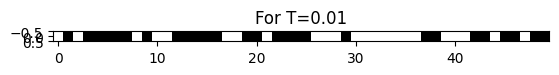

- run : 2/3


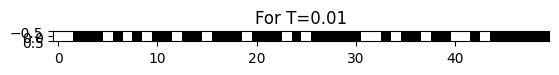

- run : 3/3


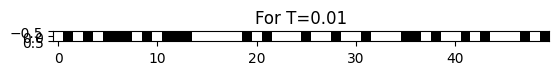

----------
beta=1.8664
- run : 1/3


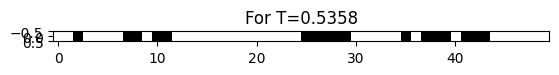

- run : 2/3


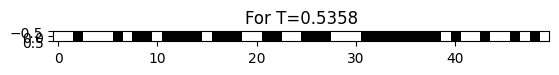

- run : 3/3


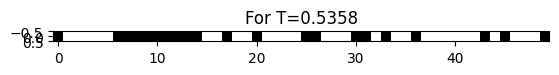

----------
beta=0.942
- run : 1/3


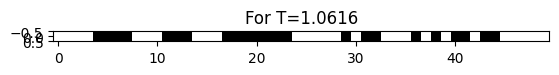

- run : 2/3


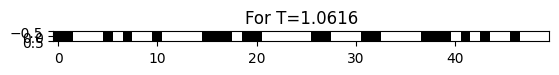

- run : 3/3


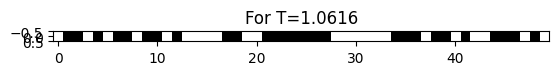

----------
beta=0.63
- run : 1/3


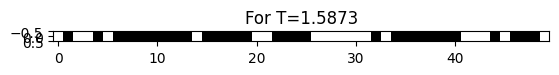

- run : 2/3


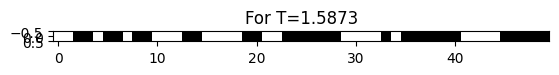

- run : 3/3


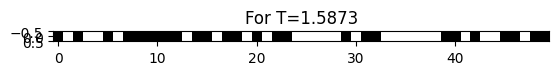

----------
beta=0.4732
- run : 1/3


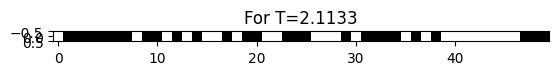

- run : 2/3


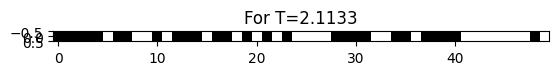

- run : 3/3


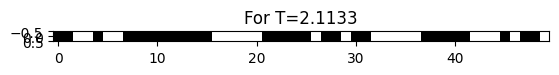

----------
beta=0.3789
- run : 1/3


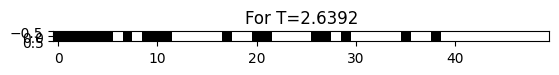

- run : 2/3


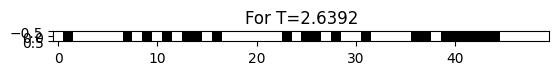

- run : 3/3


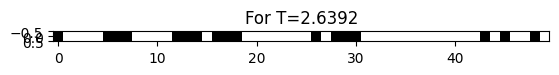

----------
beta=0.316
- run : 1/3


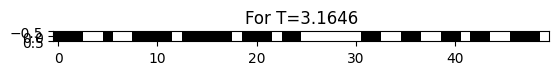

- run : 2/3


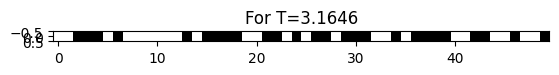

- run : 3/3


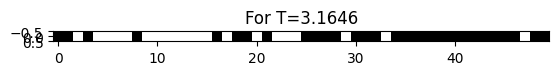

----------
beta=0.271
- run : 1/3


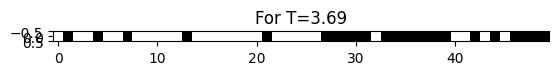

- run : 2/3


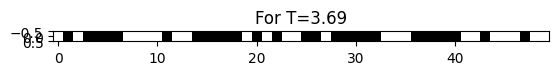

- run : 3/3


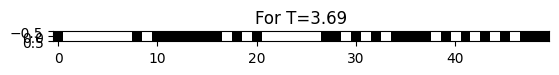

----------
beta=0.2372
- run : 1/3


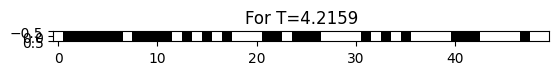

- run : 2/3


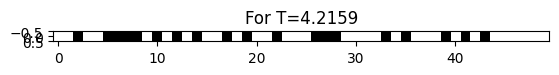

- run : 3/3


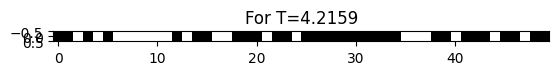

----------
beta=0.2109
- run : 1/3


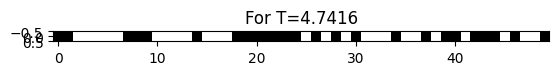

- run : 2/3


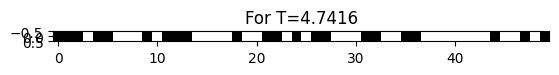

- run : 3/3


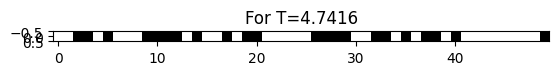

----------
beta=0.1898
- run : 1/3


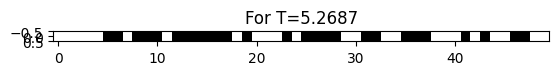

- run : 2/3


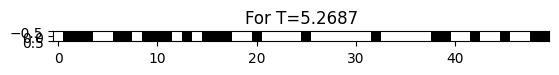

- run : 3/3


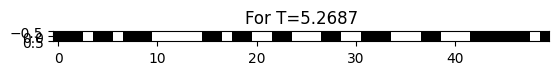

----------
beta=0.1726
- run : 1/3


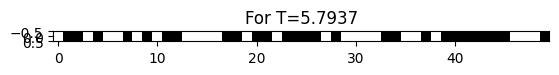

- run : 2/3


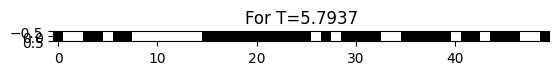

- run : 3/3


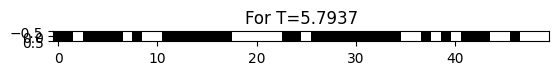

----------
beta=0.1582
- run : 1/3


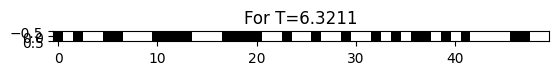

- run : 2/3


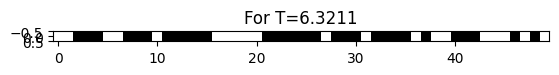

- run : 3/3


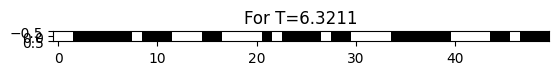

----------
beta=0.1461
- run : 1/3


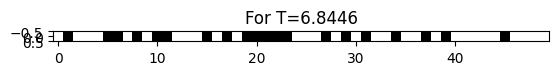

- run : 2/3


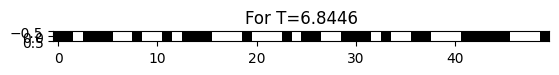

- run : 3/3


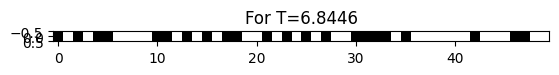

----------
beta=0.1357
- run : 1/3


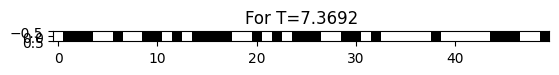

- run : 2/3


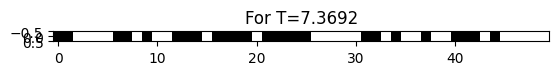

- run : 3/3


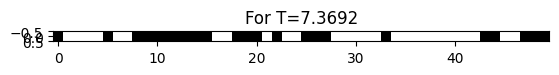

----------
beta=0.1266
- run : 1/3


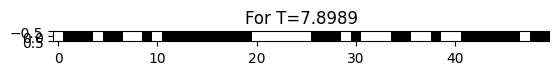

- run : 2/3


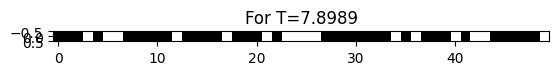

- run : 3/3


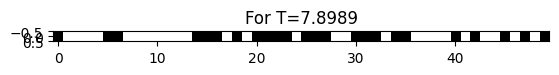

----------
beta=0.1187
- run : 1/3


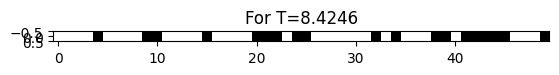

- run : 2/3


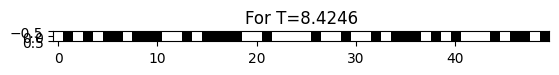

- run : 3/3


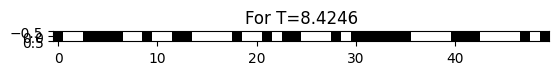

----------
beta=0.1118
- run : 1/3


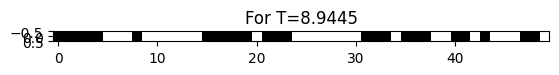

- run : 2/3


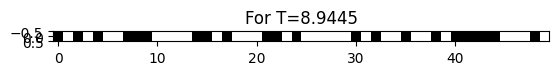

- run : 3/3


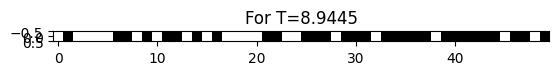

----------
beta=0.1055
- run : 1/3


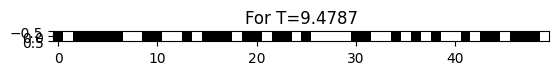

- run : 2/3


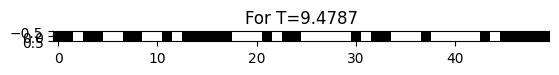

- run : 3/3


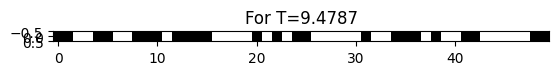

----------
beta=0.1
- run : 1/3


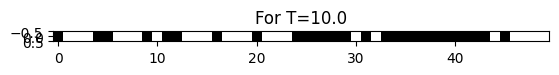

- run : 2/3


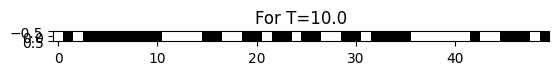

- run : 3/3


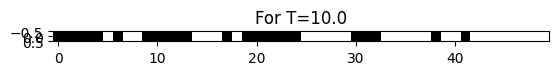

In [17]:
J = 1.

energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error = simulation_temperature_range(temp_list, Nt, n_runs)

#### Plot

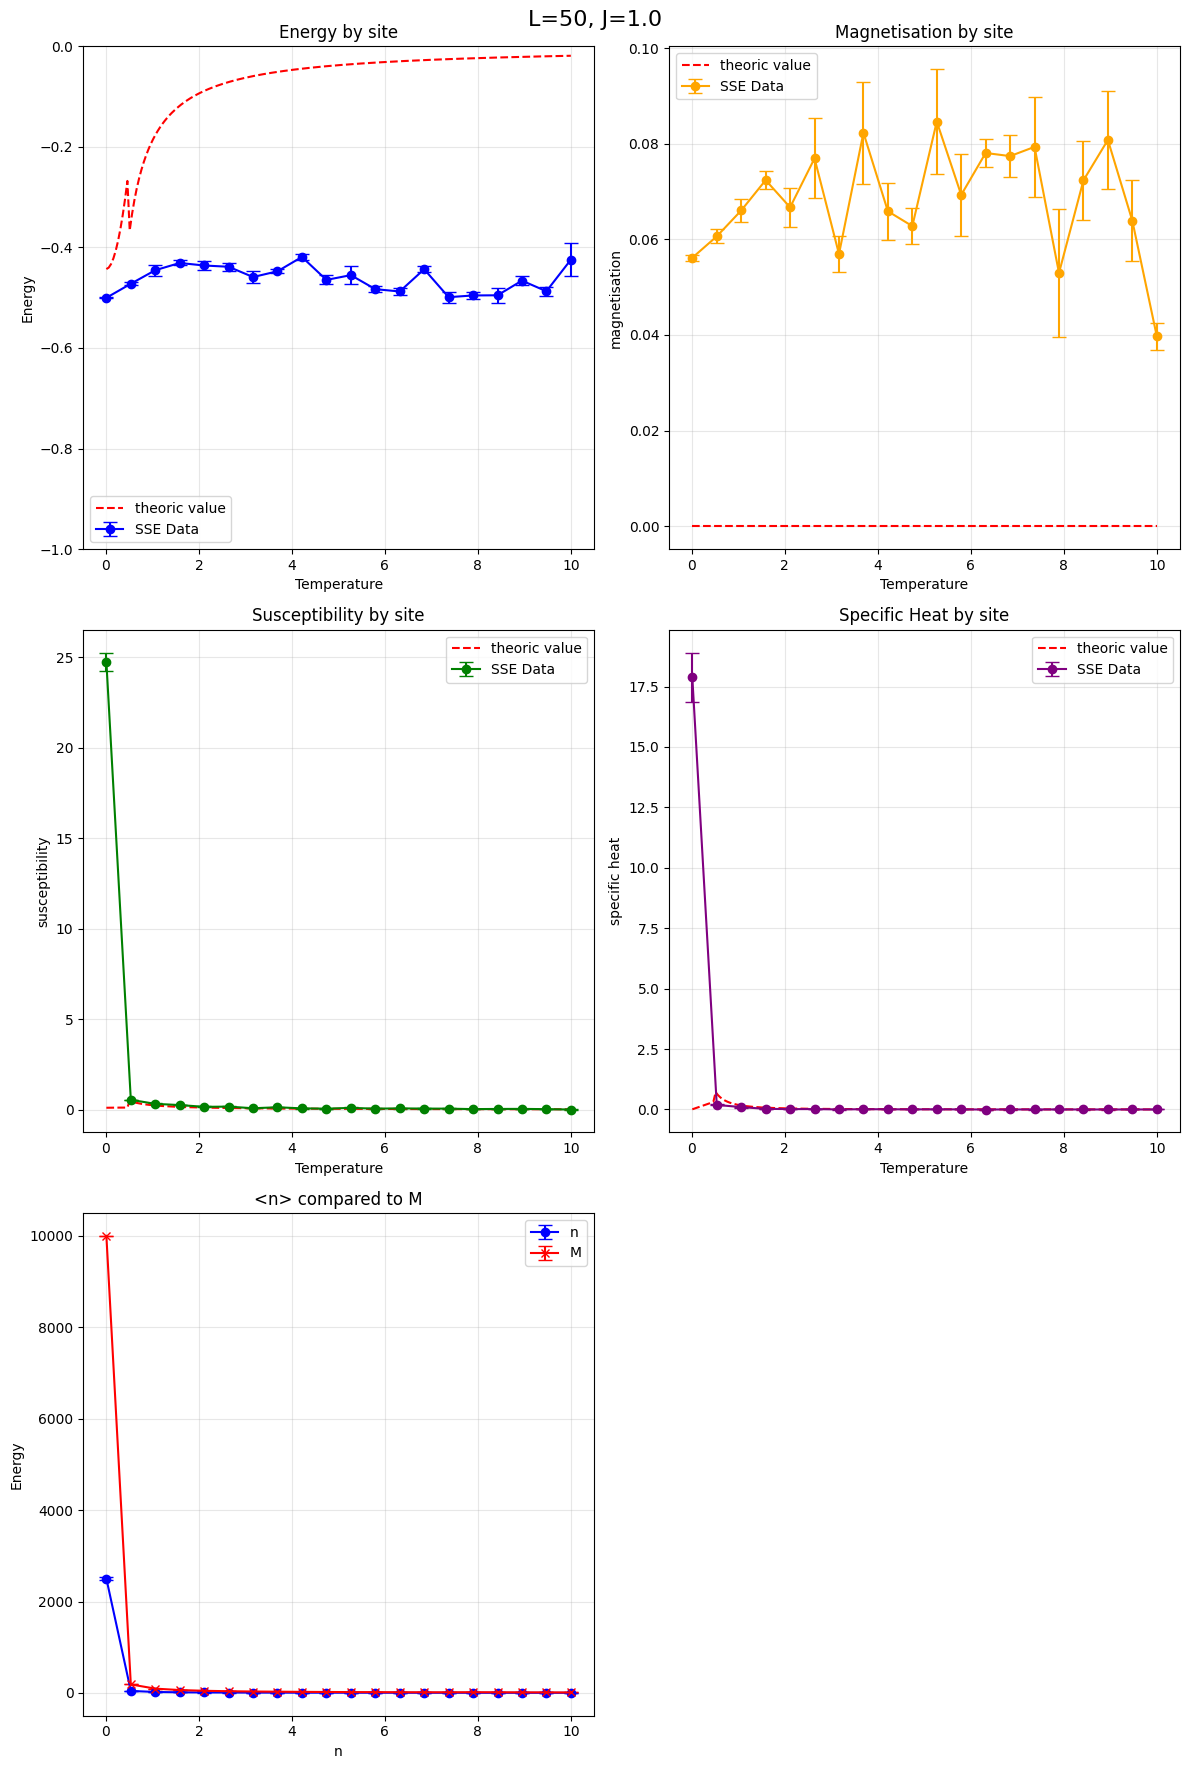

-0.500185398414685 =? -0.443147


In [18]:
plot_result(temp_list, energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error)

---

### 6.3 Ferromagnetic case : $J=-1$

----------
beta=100.0
- run : 1/3


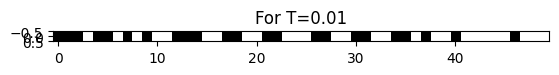

- run : 2/3


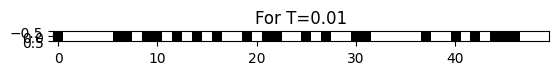

- run : 3/3


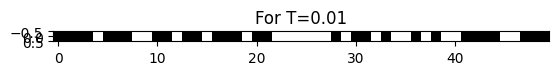

----------
beta=1.8664
- run : 1/3


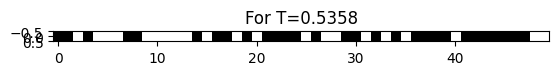

- run : 2/3


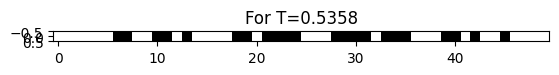

- run : 3/3


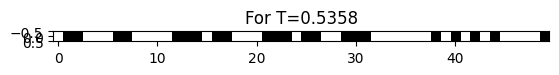

----------
beta=0.942
- run : 1/3


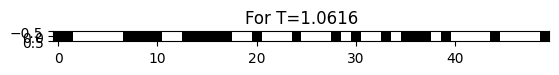

- run : 2/3


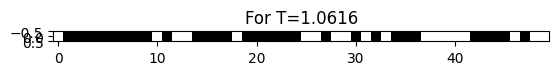

- run : 3/3


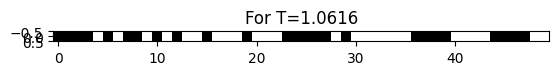

----------
beta=0.63
- run : 1/3


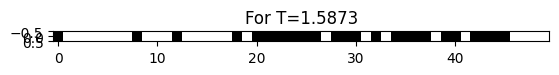

- run : 2/3


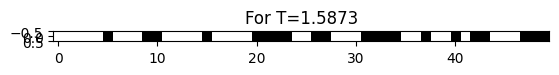

- run : 3/3


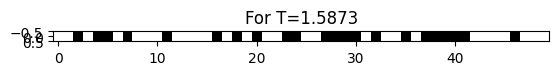

----------
beta=0.4732
- run : 1/3


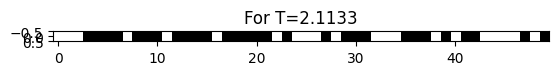

- run : 2/3


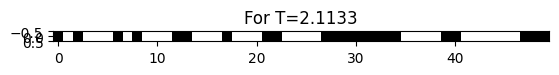

- run : 3/3


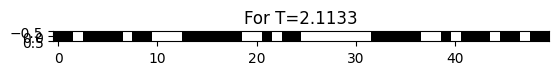

----------
beta=0.3789
- run : 1/3


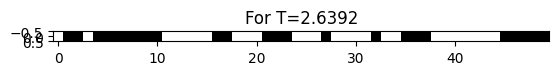

- run : 2/3


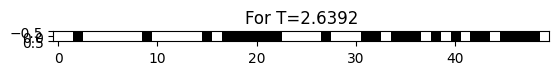

- run : 3/3


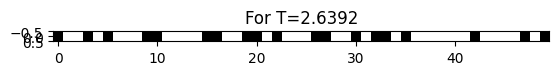

----------
beta=0.316
- run : 1/3


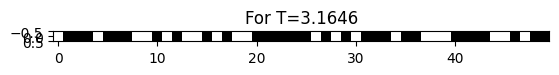

- run : 2/3


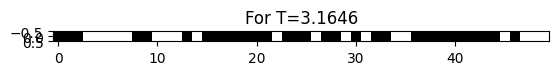

- run : 3/3


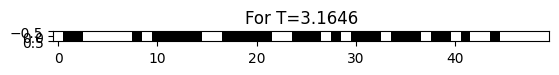

----------
beta=0.271
- run : 1/3


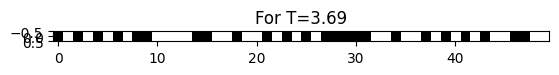

- run : 2/3


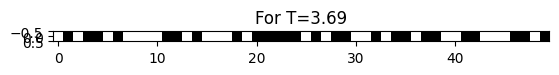

- run : 3/3


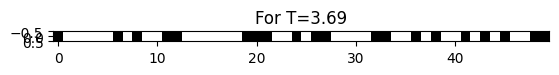

----------
beta=0.2372
- run : 1/3


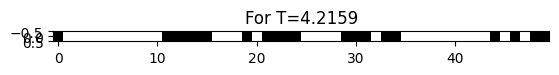

- run : 2/3


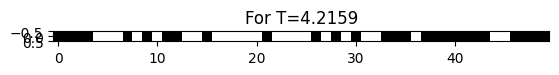

- run : 3/3


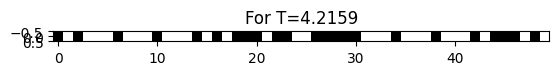

----------
beta=0.2109
- run : 1/3


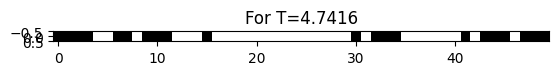

- run : 2/3


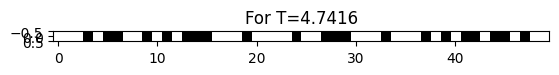

- run : 3/3


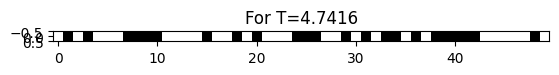

----------
beta=0.1898
- run : 1/3


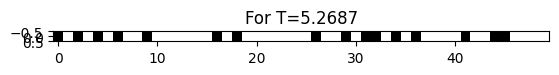

- run : 2/3


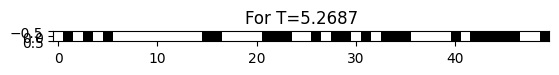

- run : 3/3


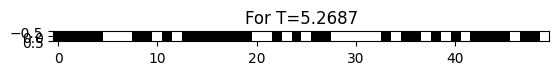

----------
beta=0.1726
- run : 1/3


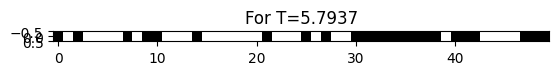

- run : 2/3


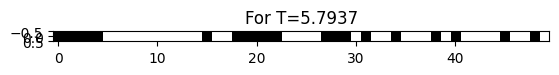

- run : 3/3


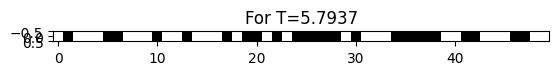

----------
beta=0.1582
- run : 1/3


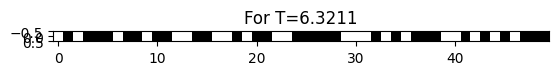

- run : 2/3


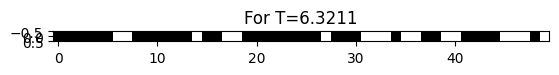

- run : 3/3


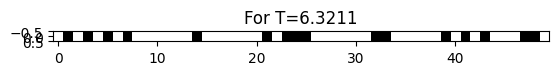

----------
beta=0.1461
- run : 1/3


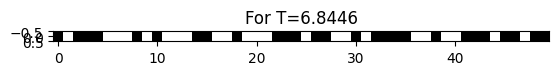

- run : 2/3


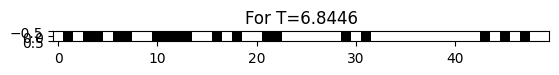

- run : 3/3


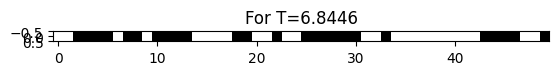

----------
beta=0.1357
- run : 1/3


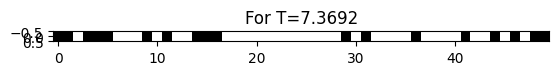

- run : 2/3


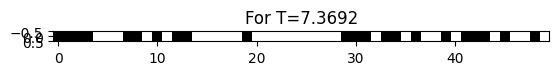

- run : 3/3


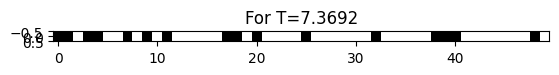

----------
beta=0.1266
- run : 1/3


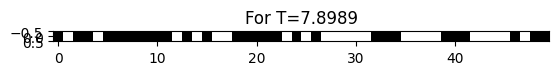

- run : 2/3


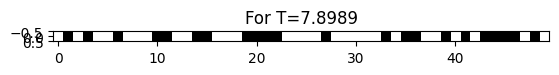

- run : 3/3


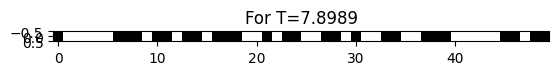

----------
beta=0.1187
- run : 1/3


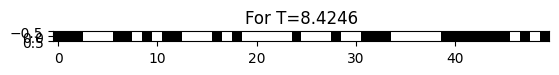

- run : 2/3


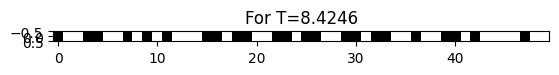

- run : 3/3


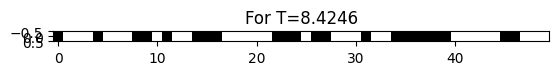

----------
beta=0.1118
- run : 1/3


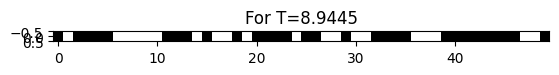

- run : 2/3


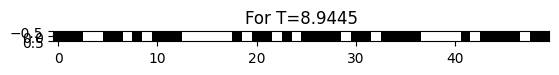

- run : 3/3


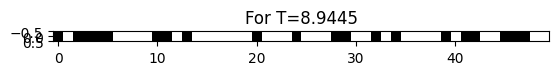

----------
beta=0.1055
- run : 1/3


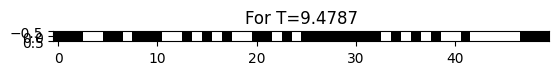

- run : 2/3


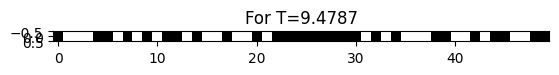

- run : 3/3


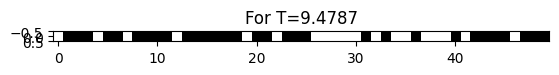

----------
beta=0.1
- run : 1/3


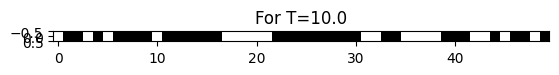

- run : 2/3


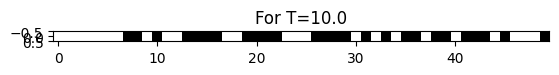

- run : 3/3


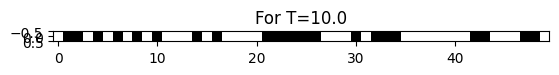

In [19]:
J = -1.

energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error = simulation_temperature_range(temp_list, Nt, n_runs)

#### Plot

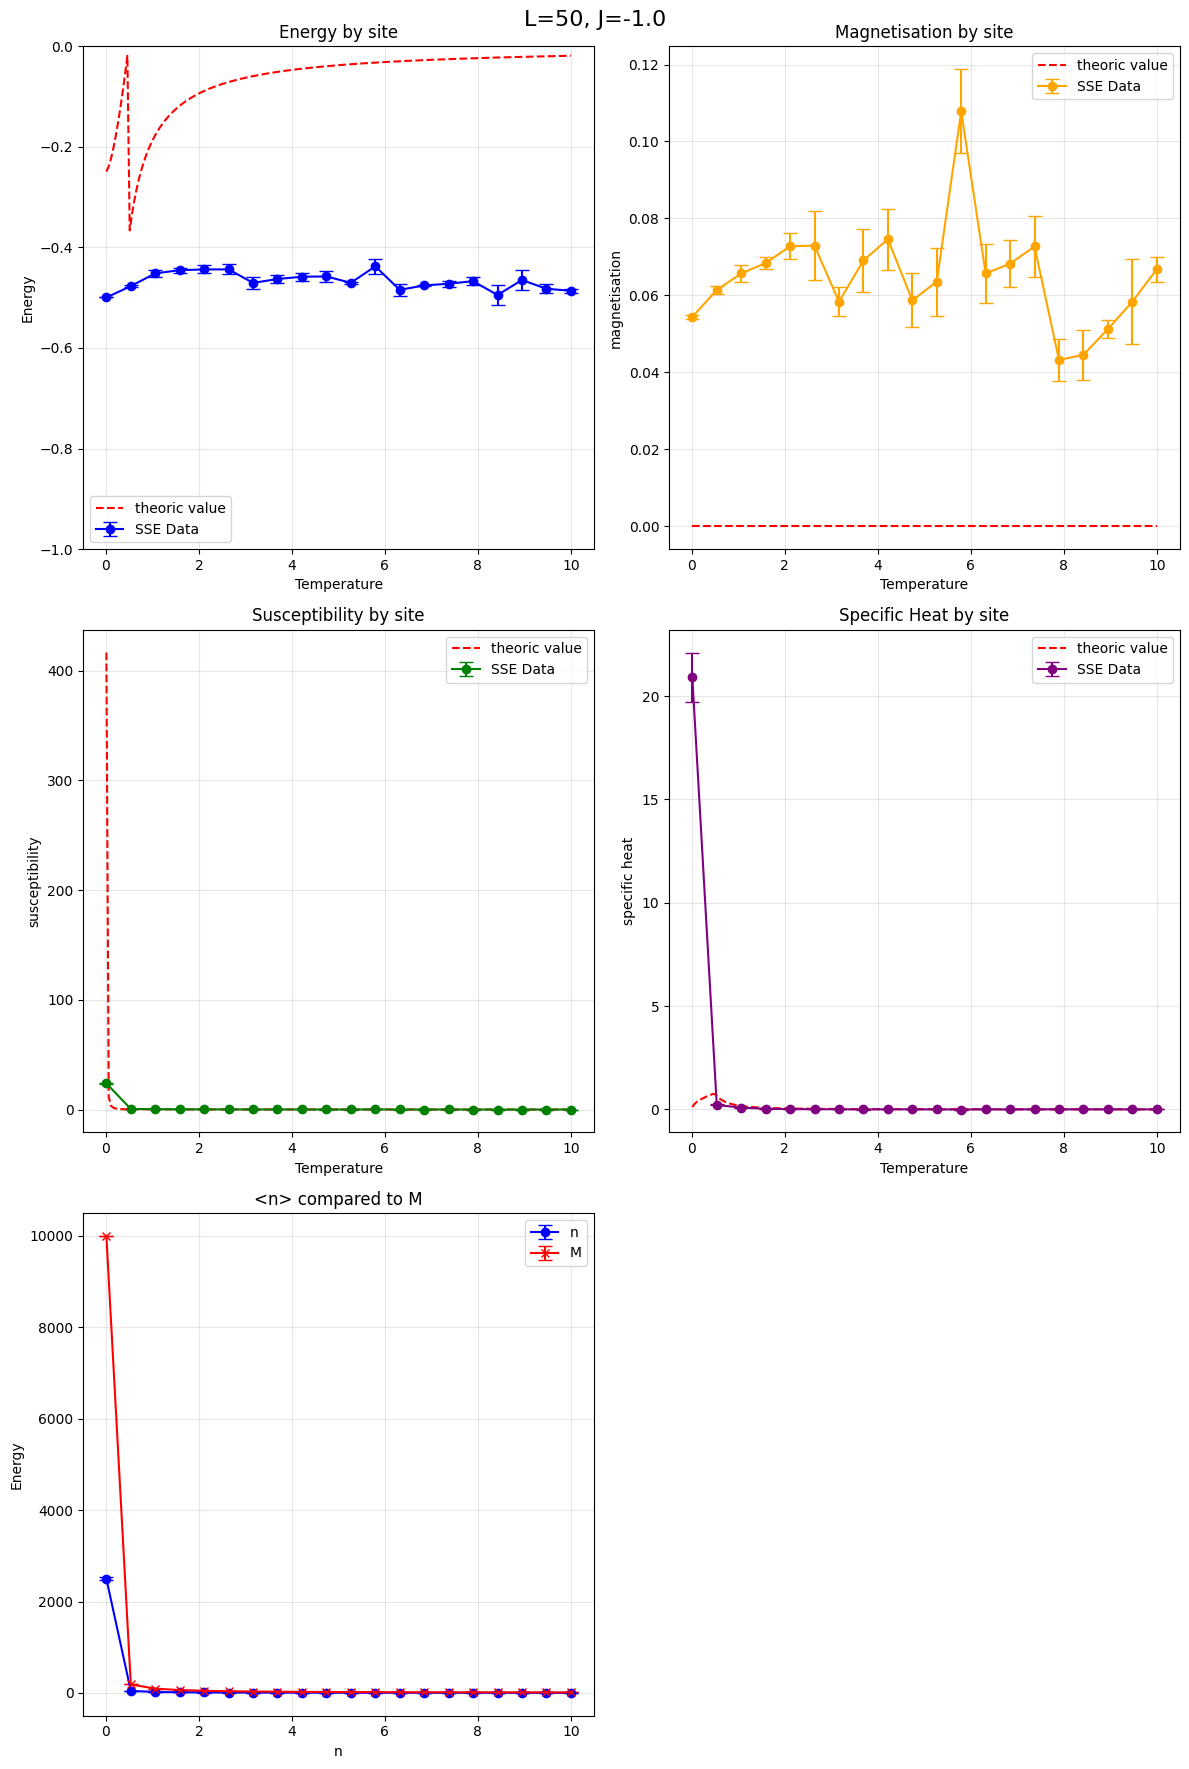

-0.4995021276595745 =? -0.25


In [20]:
plot_result(temp_list, energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error)

---

### 5.3 Observation

---

### 5.4 Conclusion

iTEBD :

In [21]:
global X, Y, Z, I, SP, SM

X = np.array([[0, 1], 
              [1, 0]], dtype=complex)
Y = np.array([[0, -1j], 
              [1j, 0]], dtype=complex)
Z = np.array([[1, 0], 
              [0, -1]], dtype=complex)
I = np.eye(2, dtype=complex)

SP = 0.5 * (X + 1j * Y)
SM = 0.5 * (X - 1j * Y)

def gate_ising_two_site(h: float, delta: float): # delta = delta tau
    """
    Build the imaginary-time two-site gate G = exp(-delta * h2)
    with h2 = sx⊗sx + sy⊗sy + sz⊗sz - (h/2)(sz⊗I + I⊗sz).
    Returns:
      G4 : shape (2,2,2,2) with indices (s1', s2', s1, s2)
      h2_4 : same shape for measuring energy <h2>
    """
    h2 = np.kron(X, X)+np.kron(Y, Y)+np.kron(Z, Z) - 0.5 * h * (np.kron(Z, I) + np.kron(I, Z))  # 4x4 Hermitian
    w, V = np.linalg.eigh(h2)
    G = V @ np.diag(np.exp(-delta * w)) @ V.conj().T                        # 4x4
    G4 = G.reshape(2, 2, 2, 2)                                              # (s1',s2',s1,s2)
    h2_4 = h2.reshape(2, 2, 2, 2)
    return G4, h2_4

# ----------------------------
# Initial iMPS: product of singlets on AB bonds
# ----------------------------
# Unit cell ...-B-A-B-A-...
# We store: GammaA (chiBA,d,chiAB), GammaB (chiAB,d,chiBA)
# with lambdas: lamAB (between A and B), lamBA (between B and A)
def init_singlet_dimer():
    # From your sheet:
    # A_{i σ k} = δ_{i,1} [[1,0],[0,-1]]_{σ,k}
    # B_{k σ l} = [[0,1],[1,0]]_{k,σ} δ_{l,1}
    chiBA, d, chiAB = 1, 2, 2
    GammaA = np.zeros((chiBA, d, chiAB), dtype=complex)
    GammaA[0, :, :] = np.array([[1, 0],
                                [0, -1]], dtype=complex)

    GammaB = np.zeros((chiAB, d, chiBA), dtype=complex)
    GammaB[:, :, 0] = np.array([[0, 1],
                                [1, 0]], dtype=complex)

    lamAB = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=float)  # Schmidt on AB
    lamBA = np.array([1.0], dtype=float)                          # Schmidt on BA
    return GammaA, GammaB, lamAB, lamBA

from numpy.linalg import inv

def apply_two_site_gate(GammaL, lamL, lamM, GammaR, lamR, G4, chi_max=32, eps=5e-2):
    """
    One iTEBD update on a bond:
      ... --lamL-- GammaL --lamM-- GammaR --lamR-- ...
    Apply gate G4 on the two physical indices of (GammaL, GammaR),
    then restore canonical form by SVD:
      - update middle Schmidt values lamM
      - update GammaL and GammaR
    Canonical convention used here:
      theta[a,s,t,c] = lamL[a] * GammaL[a,s,b] * lamM[b] * GammaR[b,t,c] * lamR[c]
    with GammaL shape (chiL, d, chiM), GammaR shape (chiM, d, chiR).
    """
    chiL, d, chiM = GammaL.shape
    chiM2, d2, chiR = GammaR.shape
    assert d == 2 and d2 == 2
    assert chiM == chiM2
    assert lamL.shape == (chiL,)
    assert lamM.shape == (chiM,)
    assert lamR.shape == (chiR,)

    # Build theta[a,s,t,c]
    theta = np.einsum('a,asb,b,btc,c->astc', lamL, GammaL, lamM, GammaR, lamR)

    # Apply gate on physical indices (s,t) -> (s',t')
    theta_g = np.einsum('STst,astc->aSTc', G4, theta)

    # Reshape to matrix for SVD: (a,S) x (T,c)
    M = theta_g.reshape(chiL * d, d * chiR)

    U, s, Vh = np.linalg.svd(M, full_matrices=False)

    # complete the code below

    # Truncation by eps and chi_max
    chi = s[s>eps].shape[0]
    if chi > chi_max:
        chi = chi_max

    U = U[:, :chi]
    Vh = Vh[:chi, :]
    s = s[:chi]

    # Renormalise state by normalising Schmidt values (keeps norms under control)
    lamM_new = s/np.sqrt(np.sum(s**2))

    # Reshape U, Vh back to Gammas
    Ur = U.reshape(chiL, d, chi)
    Vhr = Vh.reshape(chi, d, chiR)

    # Divide out the outer lambdas to keep canonical form
    if chiL > 1:
        inv_LamL = 1/lamL
        GammaL_new = np.einsum('i, ijk->ijk',inv_LamL, Ur)
    else :
        GammaL_new = Ur/lamL

    if chiR > 1:
        inv_LamR = 1/lamR
        GammaR_new = np.einsum('ijk, k->ijk',Vhr, inv_LamR)
    else :
        GammaR_new = Vhr/lamR

    return GammaL_new, lamM_new, GammaR_new

def two_site_expectation(GammaL, lamL, lamM, GammaR, lamR, O4):
    """
    Expectation value of a two-site operator O4[s,t,s',t'] on the bond (L,R),
    using theta[a,s,t,c] as above.
    Returns <O>.
    """
    theta = np.einsum('a,asb,b,btc,c->astc', lamL, GammaL, lamM, GammaR, lamR)
    norm = np.einsum('astc,astc->', theta.conj(), theta).real
    val = np.einsum('astc,stuv,auvc->', theta.conj(), O4, theta)
    return (val / norm)

def ite_bd_demo(h=0.5, delta=0.1, nsteps=10, chi_max=32, eps=5e-2, show_print=False):
    G4, h2_4 = gate_ising_two_site(h=h, delta=delta)

    # Operators for correlation c = <sigma^+_A sigma^-_B>
    corr_AB = np.kron(SP, SM).reshape(2, 2, 2, 2)  # (s,t,s',t')

    GammaA, GammaB, lamAB, lamBA = init_singlet_dimer()

    e_list, c_list, Sab_list, Sba_list = [], [], [], []

    for it in range(nsteps):
        # --- Gate on AB bond ---
        # structure: ... --lamBA-- A --lamAB-- B --lamBA-- ...
        GammaA, lamAB, GammaB = apply_two_site_gate(
            GammaA, lamBA, lamAB, GammaB, lamBA, G4, chi_max=chi_max, eps=eps
        )

        # --- Gate on BA bond ---
        # structure: ... --lamAB-- B --lamBA-- A --lamAB-- ...
        GammaB, lamBA, GammaA = apply_two_site_gate(
            GammaB, lamAB, lamBA, GammaA, lamAB, G4, chi_max=chi_max, eps=eps
        )

        # --- Measurements (AB and BA bonds; average them) ---
        eAB = two_site_expectation(GammaA, lamBA, lamAB, GammaB, lamBA, h2_4).real
        eBA = two_site_expectation(GammaB, lamAB, lamBA, GammaA, lamAB, h2_4).real
        e = 0.5 * (eAB + eBA)

        cAB = two_site_expectation(GammaA, lamBA, lamAB, GammaB, lamBA, corr_AB)
        cBA = two_site_expectation(GammaB, lamAB, lamBA, GammaA, lamAB, corr_AB)
        c = 0.5 * (cAB + cBA)


        e_list.append(e)
        c_list.append(c.real)

        if it%(nsteps//10)==0 and show_print :
          print(f"it={it:03d}  e={e:+.12f}  c={c:+.12f}  chiAB={len(lamAB)} chiBA={len(lamBA)}")

    return {
        "e": np.array(e_list),
        "c": np.array(c_list),
        "S_AB": np.array(Sab_list),
        "S_BA": np.array(Sba_list),
        "GammaA": GammaA, "GammaB": GammaB, "lamAB": lamAB, "lamBA": lamBA
    }

In [22]:
h_list = [0]
Nt = 100
dt = 0.1
chi_max = 50
eps = 0.05

out = {}
for h in h_list :
    out[str(h)] = ite_bd_demo(h=h, delta=dt, nsteps=Nt, chi_max=chi_max, eps=eps, show_print=True)

it=000  e=-1.716136976731  c=-0.286022829455+0.000000000000j  chiAB=2 chiBA=4
it=010  e=-1.720394496774  c=-0.286732416129+0.000000000000j  chiAB=2 chiBA=4
it=020  e=-1.718983947353  c=-0.286497324559+0.000000000000j  chiAB=2 chiBA=4
it=030  e=-1.718952425989  c=-0.286492070998+0.000000000000j  chiAB=2 chiBA=4
it=040  e=-1.718951722788  c=-0.286491953798+0.000000000000j  chiAB=2 chiBA=4
it=050  e=-1.718951707101  c=-0.286491951183+0.000000000000j  chiAB=2 chiBA=4
it=060  e=-1.718951706751  c=-0.286491951125+0.000000000000j  chiAB=2 chiBA=4
it=070  e=-1.718951706743  c=-0.286491951124+0.000000000000j  chiAB=2 chiBA=4
it=080  e=-1.718951706743  c=-0.286491951124+0.000000000000j  chiAB=2 chiBA=4
it=090  e=-1.718951706743  c=-0.286491951124+0.000000000000j  chiAB=2 chiBA=4


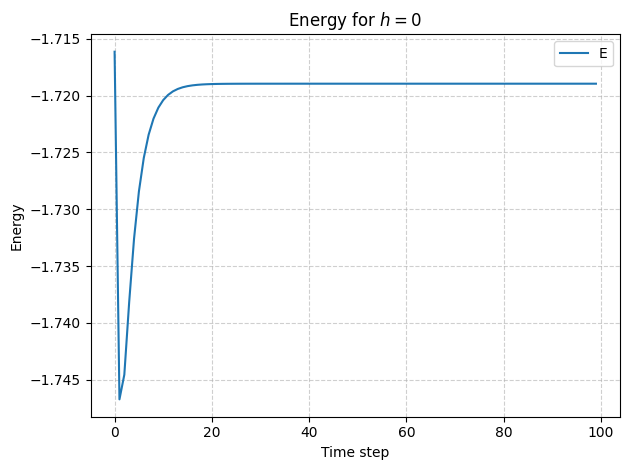

In [23]:
h = h_list[0]
# Récupération des données
data = out[str(h)]

# Plot sur l'axe spécifique
plt.plot(data["e"], label="E")

# Personnalisation de chaque sous-graphique
plt.title(f"Energy for $h = {h}$")
plt.xlabel("Time step")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajuste automatiquement les espacements pour éviter les chevauchements
plt.show()